In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    max_error
)

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

In [3]:
DATA_PATH = "userData.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10000, 28)


,age,gender,height_cm,weight_kg,bmi,physical_activity_level,steps_per_day,sleep_hours,diabetes_duration_years,hba1c_percent,...,smoking_status,alcohol_use,primary_goal,daily_calories_kcal,daily_carbohydrates_g,daily_protein_g,daily_fat_g,daily_fiber_g,ckd_stage_label,bmi_class_label
0,58,Female,167.6,56.3,20.0,Moderate,8288,6.5,0.9,8.94,...,0,0,Weight loss,1207.2,85.0,63.4,51.0,38.9,G1,Normal
1,92,Female,159.4,71.9,28.3,Sedentary,3530,7.0,24.2,7.27,...,0,1,Maintenance,1000.0,98.0,43.1,42.2,31.5,G3a,Overweight
2,81,Male,175.8,89.0,28.8,Sedentary,3743,6.6,13.2,8.62,...,0,0,Maintenance,1521.9,117.7,76.1,64.3,34.2,G2,Overweight
3,66,Female,166.8,47.6,17.1,Sedentary,3046,5.0,2.5,6.60,...,0,0,Weight loss,1000.0,118.9,55.0,33.8,25.0,G1,Underweight
4,64,Female,162.1,74.0,28.2,Light,5852,6.0,6.0,5.70,...,0,0,Weight loss,1005.2,129.7,59.2,32.8,29.0,G2,Overweight


In [4]:
print("Missing Values Per Column:")
display(df.isnull().sum().sort_values(ascending=False))

print("Duplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T)

Missing Values Per Column:


age                           0
gender                        0
height_cm                     0
weight_kg                     0
bmi                           0
physical_activity_level       0
steps_per_day                 0
sleep_hours                   0
diabetes_duration_years       0
hba1c_percent                 0
fasting_glucose_mg_dl         0
postprandial_glucose_mg_dl    0
triglycerides_mg_dl           0
ldl_cholesterol_mg_dl         0
hdl_cholesterol_mg_dl         0
systolic_bp_mmhg              0
diastolic_bp_mmhg             0
egfr_ml_min_1_73m2            0
smoking_status                0
alcohol_use                   0
primary_goal                  0
daily_calories_kcal           0
daily_carbohydrates_g         0
daily_protein_g               0
daily_fat_g                   0
daily_fiber_g                 0
ckd_stage_label               0
bmi_class_label               0
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,10000.0,NaN,NaN,NaN,60.2627,17.942126,18.0,46.0,60.0,73.0,95.0
gender,10000,2,Male,5443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,10000.0,NaN,NaN,NaN,169.05035,9.175308,140.5,162.3,168.8,175.8,200.0
weight_kg,10000.0,NaN,NaN,NaN,85.90794,19.321703,35.2,73.1,85.2,98.0,159.9
bmi,10000.0,NaN,NaN,NaN,29.96979,5.865093,15.4,26.6,30.0,33.6,48.0
physical_activity_level,10000,4,Sedentary,3533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
steps_per_day,10000.0,NaN,NaN,NaN,6207.4056,3367.368645,500.0,3521.0,5481.5,8100.0,23438.0
sleep_hours,10000.0,NaN,NaN,NaN,6.4923,1.179678,3.5,5.7,6.5,7.3,10.0
diabetes_duration_years,10000.0,NaN,NaN,NaN,6.27623,5.694662,0.0,0.9,5.2,10.2,27.6
hba1c_percent,10000.0,NaN,NaN,NaN,7.819717,1.256815,5.7,6.89,7.79,8.68,14.0


In [5]:
TARGET_COLS = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

feature_cols = [c for c in df.columns if c not in TARGET_COLS]

print("Features:", len(feature_cols))
print("Targets:", len(TARGET_COLS))

Features: 23
Targets: 5


In [6]:
X = df[feature_cols].copy()
y = df[TARGET_COLS].copy()

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric Features:", len(numeric_cols))
print("Categorical Features:", len(cat_cols))

Numeric Features: 18
Categorical Features: 5


C:\Users\gokul\AppData\Local\Temp\ipykernel_22044\1200141578.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [7]:
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (8000, 23) (8000, 5)
Test : (2000, 23) (2000, 5)


In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # handles NULL
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [9]:
def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100)


def smape(y_true, y_pred, eps=1e-6):
    return float(
        100 * np.mean(
            2 * np.abs(y_pred - y_true) /
            (np.abs(y_true) + np.abs(y_pred) + eps)
        )
    )


def multioutput_max_error(y_true, y_pred):
    """
    Compute max error per target and return mean.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    max_errors = []

    for i in range(y_true.shape[1]):
        max_err = np.max(np.abs(y_true[:, i] - y_pred[:, i]))
        max_errors.append(max_err)

    return float(np.mean(max_errors))


def compute_metrics(y_true, y_pred):

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred, multioutput="uniform_average"),
        "ExplainedVar": explained_variance_score(
            y_true, y_pred, multioutput="uniform_average"
        ),
        "MaxError": multioutput_max_error(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
        "SMAPE_%": smape(y_true, y_pred)
    }

In [10]:
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

In [11]:
models = {
    "Ridge": Ridge(alpha=1.0),
    
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.3),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
}
if XGBOOST_AVAILABLE:
    models["XGBoost"] = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    )


models["LightGBM"] = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    )

print("Models to train:")
print("\nModels to train:")
for name in models.keys():
    print(" -", name)

print("\nTotal Models:", len(models))

Models to train:

Models to train:
 - Ridge
 - ElasticNet
 - RandomForest
 - ExtraTrees
 - XGBoost
 - LightGBM

Total Models: 6


In [12]:
def kfold_compare_models(models, X, y, preprocess, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    results = []

    for model_name, model in models.items():
        fold_metrics = []
        print(f"\nTraining: {model_name}")

        for fold, (tr_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            pipe = Pipeline([
                ("prep", preprocess),
                ("model", model)
            ])

            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)

            metrics = compute_metrics(y_val, y_pred)
            fold_metrics.append(metrics)

            print(f"Fold {fold}:", metrics)

        avg_metrics = {
            "Model": model_name,
            "MAE": np.mean([m["MAE"] for m in fold_metrics]),
            "RMSE": np.mean([m["RMSE"] for m in fold_metrics]),
            "R2": np.mean([m["R2"] for m in fold_metrics]),
            "ExplainedVar": np.mean([m["ExplainedVar"] for m in fold_metrics]),
            "MaxError": np.mean([m["MaxError"] for m in fold_metrics]),
            "MAPE_%": np.mean([m["MAPE_%"] for m in fold_metrics]),
            "SMAPE_%": np.mean([m["SMAPE_%"] for m in fold_metrics]),
        }

        results.append(avg_metrics)

    return pd.DataFrame(results).sort_values(by="RMSE")

In [13]:
cv_results = kfold_compare_models(
    models,
    X_train,
    y_train,
    preprocess,
    n_splits=5,
    seed=RANDOM_SEED
)

display(cv_results)


Training: Ridge
Fold 1: {'MAE': 18.30052664888134, 'RMSE': np.float64(44.95228946213797), 'R2': 0.8986099243665, 'ExplainedVar': 0.8988289394227864, 'MaxError': 170.17917228737946, 'MAPE_%': 6.884561017150443, 'SMAPE_%': 7.107041616447077}
Fold 2: {'MAE': 17.757946214136282, 'RMSE': np.float64(42.83510423315089), 'R2': 0.9002965820519684, 'ExplainedVar': 0.900344690369938, 'MaxError': 146.78759674215584, 'MAPE_%': 6.815080671839048, 'SMAPE_%': 7.03072667309306}
Fold 3: {'MAE': 17.94248303950213, 'RMSE': np.float64(43.519038115398935), 'R2': 0.8940601780684256, 'ExplainedVar': 0.8940991978848297, 'MaxError': 166.16274336026652, 'MAPE_%': 6.905491605320097, 'SMAPE_%': 7.135694138213249}
Fold 4: {'MAE': 17.91617317471453, 'RMSE': np.float64(43.55740058538653), 'R2': 0.8934901655779267, 'ExplainedVar': 0.8937289249723868, 'MaxError': 172.03687103711383, 'MAPE_%': 6.968239010489434, 'SMAPE_%': 7.17461919764151}
Fold 5: {'MAE': 18.236580920047373, 'RMSE': np.float64(45.06297070249304), 'R2'

c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.184e+06, tolerance: 1.323e+05
  model = cd_fast.enet_coordinate_descent(


Fold 1: {'MAE': 18.33126529762365, 'RMSE': np.float64(44.9335369379738), 'R2': 0.8985329271041145, 'ExplainedVar': 0.898754936134954, 'MaxError': 168.60095243044637, 'MAPE_%': 6.883851402424137, 'SMAPE_%': 7.104270944366829}


c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.233e+06, tolerance: 1.333e+05
  model = cd_fast.enet_coordinate_descent(


Fold 2: {'MAE': 17.787271553450474, 'RMSE': np.float64(42.82709567158118), 'R2': 0.9003335137157389, 'ExplainedVar': 0.9003831973688128, 'MaxError': 146.35814223541485, 'MAPE_%': 6.808607870175666, 'SMAPE_%': 7.0212202102840875}


...

Fold 3: {'MAE': 7.611945108769741, 'RMSE': np.float64(17.644403977208096), 'R2': 0.9822157529980016, 'ExplainedVar': 0.9822272930321295, 'MaxError': 69.99351070836875, 'MAPE_%': 2.580203775887404, 'SMAPE_%': 2.569687761294631}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3737
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 39
[LightGBM] [Info] Start training from score 1628.480375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3737
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 39
[LightGBM] [Info] Start training from score 149.785391
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 

c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac

Fold 4: {'MAE': 8.038938431614943, 'RMSE': np.float64(19.30681196281349), 'R2': 0.9808307092079719, 'ExplainedVar': 0.980837829773211, 'MaxError': 75.13563811852126, 'MAPE_%': 2.721721713291791, 'SMAPE_%': 2.704597135317503}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3738
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 39
[LightGBM] [Info] Start training from score 1623.663390
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3738
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 39
[LightGBM] [Info] Start training from score 149.247141
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.

c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac

,Model,MAE,RMSE,R2,ExplainedVar,MaxError,MAPE_%,SMAPE_%
5,LightGBM,7.785105,18.440368,0.982258,0.982295,75.745589,2.617066,2.603351
4,XGBoost,8.120821,19.261632,0.981298,0.981334,75.383060,2.741267,2.726427
3,ExtraTrees,17.910714,37.002150,0.843378,0.843559,125.326816,8.343502,7.980484
2,RandomForest,18.601856,38.542842,0.844751,0.844939,126.448587,8.363381,8.018791
0,Ridge,18.030742,43.985361,0.895829,0.895955,162.461327,6.902464,7.133463
1,ElasticNet,18.069607,44.018656,0.895761,0.895889,162.091066,6.902855,7.132303


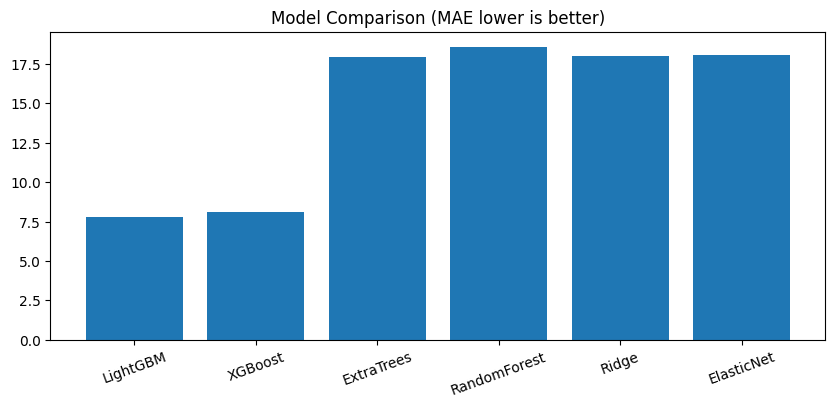

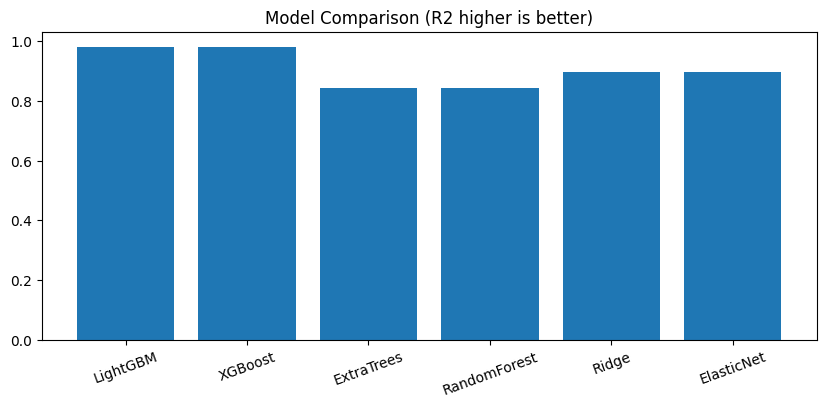

In [14]:
plt.figure(figsize=(10, 4))
plt.bar(cv_results["Model"], cv_results["MAE"])
plt.title("Model Comparison (MAE lower is better)")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(cv_results["Model"], cv_results["R2"])
plt.title("Model Comparison (R2 higher is better)")
plt.xticks(rotation=20)
plt.show()

In [15]:
best_model_name = cv_results.iloc[0]["Model"]
print("Best Model:", best_model_name)

best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", best_model)
])

final_pipeline.fit(X_train, y_train)

y_test_pred = final_pipeline.predict(X_test)

test_metrics = compute_metrics(y_test, y_test_pred)

print("Test Metrics:")
print(test_metrics)

Best Model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3743
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 39
[LightGBM] [Info] Start training from score 1624.081962
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3743
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 39
[LightGBM] [Info] Start training from score 149.517475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3743
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 39
[Lig

c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac

In [16]:
# =====================================================
# SAVE ALL MODELS 
# =====================================================

import os
import joblib

os.makedirs("weights", exist_ok=True)

trained_models = {}

for model_name, model in models.items():

    print(f"\nTraining  model: {model_name}")

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    file_path = f"weights/{model_name}_pipeline.pkl"
    joblib.dump(pipe, file_path)

    trained_models[model_name] = pipe

    print(f"✅ Saved: {file_path}")

print("\n🎉 All models saved successfully!")


Training  model: Ridge
✅ Saved: weights/Ridge_pipeline.pkl

Training  model: ElasticNet


c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.778e+06, tolerance: 1.672e+05
  model = cd_fast.enet_coordinate_descent(


✅ Saved: weights/ElasticNet_pipeline.pkl

Training  model: RandomForest
✅ Saved: weights/RandomForest_pipeline.pkl

Training  model: ExtraTrees
✅ Saved: weights/ExtraTrees_pipeline.pkl

Training  model: XGBoost
✅ Saved: weights/XGBoost_pipeline.pkl

Training  model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000832 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3743
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 39
[LightGBM] [Info] Start training from score 1624.081962
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000752 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3743
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 39
[LightGBM] [Info] Start training from score 149.517475
[LightGBM] [Info] Auto-choosing col-w

In [24]:
import os
import joblib
import pandas as pd
import numpy as np

# =====================================================
# CONFIG
# =====================================================

model_path = r"weights/LightGBM_pipeline.pkl"
output_csv_path = "predicted_nutrition_results.csv"

# =====================================================
# LOAD MODEL
# =====================================================

def load_model(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found at {path}")
    return joblib.load(path)

loaded_model = load_model(model_path)
print("✅ Model Loaded Successfully")

# =====================================================
# SAFE PREDICTION FUNCTION
# =====================================================

def predict_single(model, sample_dict):

    sample_df = pd.DataFrame([sample_dict])

    # Expected raw features before preprocessing
    expected_features = model.named_steps["prep"].feature_names_in_

    # Add missing columns as np.nan (IMPORTANT FIX)
    for col in expected_features:
        if col not in sample_df.columns:
            sample_df[col] = np.nan   #  use np.nan, NOT pd.NA

    # Keep correct column order
    sample_df = sample_df[expected_features]

    # Prediction
    prediction = model.predict(sample_df)[0]

    # Use your known targets
    TARGET_COLS = [
        "daily_calories_kcal",
        "daily_carbohydrates_g",
        "daily_protein_g",
        "daily_fat_g",
        "daily_fiber_g"
    ]

    return dict(zip(TARGET_COLS, prediction))

# =====================================================
# SAMPLE INPUT
# =====================================================

sample_input = {
    "age": 20,
    "gender": "Female",
    "height_cm": 110.0,
    "weight_kg": 30.0,
    "bmi": 28.0,
    "physical_activity_level": "Active",
    "steps_per_day": 2500,
    "sleep_hours": 8.0,
    "diabetes_duration_years": 20.0,
    "hba1c_percent": 5.7,
    "fasting_glucose_mg_dl": 175.0,
    "postprandial_glucose_mg_dl": 260.0,
    "triglycerides_mg_dl": 240.0,
    "ldl_cholesterol_mg_dl": 170.0,
    "hdl_cholesterol_mg_dl": 35.0,
    "systolic_bp_mmHg": 145.0,
    "diastolic_bp_mmHg": 95.0,
    "egfr_ml_min_1_73m2": 55.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Maintence"
}

# =====================================================
# RUN PREDICTION
# =====================================================

preds = predict_single(loaded_model, sample_input)

print("\n Predictions:")
for k, v in preds.items():
    print(f"{k}: {float(v):.2f}")

# Save output
pd.DataFrame([preds]).to_csv(output_csv_path, index=False)
print(f"\n✅ Saved to {output_csv_path}")

✅ Model Loaded Successfully

 Predictions:
daily_calories_kcal: 1963.57
daily_carbohydrates_g: 180.44
daily_protein_g: 42.12
daily_fat_g: 67.56
daily_fiber_g: 38.59

✅ Saved to predicted_nutrition_results.csv


c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac

In [18]:
import os
import joblib
import pandas as pd
import numpy as np

# =====================================================
# CONFIG
# =====================================================

model_path = r"weights/LightGBM_pipeline.pkl"
output_csv_path = "predicted_nutrition_results_20_patients.csv"

# =====================================================
# LOAD MODEL
# =====================================================

def load_model(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found at {path}")
    return joblib.load(path)

loaded_model = load_model(model_path)
print("✅ Model Loaded Successfully\n")

# =====================================================
# SAFE PREDICTION FUNCTION
# =====================================================

def predict_single(model, sample_dict):
    sample_df = pd.DataFrame([sample_dict])

    expected_features = model.named_steps["prep"].feature_names_in_

    for col in expected_features:
        if col not in sample_df.columns:
            sample_df[col] = np.nan

    sample_df = sample_df[expected_features]

    prediction = model.predict(sample_df)[0]

    TARGET_COLS = [
        "daily_calories_kcal",
        "daily_carbohydrates_g",
        "daily_protein_g",
        "daily_fat_g",
        "daily_fiber_g"
    ]

    return dict(zip(TARGET_COLS, prediction))

# =====================================================
# 20 DIVERSE PATIENT TEST CASES
# Each patient represents a distinct clinical profile
# =====================================================

patients = [

    # ── 1. Young athletic male, well-controlled T2D ──────────────────────────
    {
        "_label": "P01 | Young Athletic Male – Well-Controlled",
        "age": 25, "gender": "Male", "height_cm": 182.0, "weight_kg": 78.0,
        "bmi": 23.6, "physical_activity_level": "High",
        "steps_per_day": 12000, "sleep_hours": 8.0,
        "diabetes_duration_years": 2.0, "hba1c_percent": 5.8,
        "fasting_glucose_mg_dl": 95.0, "postprandial_glucose_mg_dl": 140.0,
        "triglycerides_mg_dl": 110.0, "ldl_cholesterol_mg_dl": 90.0,
        "hdl_cholesterol_mg_dl": 65.0, "systolic_bp_mmHg": 115.0,
        "diastolic_bp_mmHg": 72.0, "egfr_ml_min_1_73m2": 105.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Muscle gain"
    },

    # ── 2. Middle-aged obese female, poor control, hypertension ───────────────
    {
        "_label": "P02 | Middle-Aged Obese Female – Poor Control + HTN",
        "age": 52, "gender": "Female", "height_cm": 158.0, "weight_kg": 98.0,
        "bmi": 39.3, "physical_activity_level": "Sedentary",
        "steps_per_day": 1500, "sleep_hours": 5.5,
        "diabetes_duration_years": 12.0, "hba1c_percent": 9.2,
        "fasting_glucose_mg_dl": 210.0, "postprandial_glucose_mg_dl": 310.0,
        "triglycerides_mg_dl": 290.0, "ldl_cholesterol_mg_dl": 180.0,
        "hdl_cholesterol_mg_dl": 32.0, "systolic_bp_mmHg": 158.0,
        "diastolic_bp_mmHg": 98.0, "egfr_ml_min_1_73m2": 68.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Weight loss"
    },

    # ── 3. Elderly male, long-duration T2D, kidney disease ───────────────────
    {
        "_label": "P03 | Elderly Male – Long T2D + CKD Stage 3",
        "age": 72, "gender": "Male", "height_cm": 168.0, "weight_kg": 74.0,
        "bmi": 26.2, "physical_activity_level": "Low",
        "steps_per_day": 2000, "sleep_hours": 6.0,
        "diabetes_duration_years": 25.0, "hba1c_percent": 7.8,
        "fasting_glucose_mg_dl": 160.0, "postprandial_glucose_mg_dl": 240.0,
        "triglycerides_mg_dl": 195.0, "ldl_cholesterol_mg_dl": 130.0,
        "hdl_cholesterol_mg_dl": 40.0, "systolic_bp_mmHg": 148.0,
        "diastolic_bp_mmHg": 88.0, "egfr_ml_min_1_73m2": 38.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Blood sugar control"
    },

    # ── 4. Young female, T1D-like profile, underweight ───────────────────────
    {
        "_label": "P04 | Young Female – Underweight, Tight Control",
        "age": 22, "gender": "Female", "height_cm": 163.0, "weight_kg": 48.0,
        "bmi": 18.1, "physical_activity_level": "Moderate",
        "steps_per_day": 7000, "sleep_hours": 7.5,
        "diabetes_duration_years": 5.0, "hba1c_percent": 6.1,
        "fasting_glucose_mg_dl": 88.0, "postprandial_glucose_mg_dl": 130.0,
        "triglycerides_mg_dl": 85.0, "ldl_cholesterol_mg_dl": 75.0,
        "hdl_cholesterol_mg_dl": 72.0, "systolic_bp_mmHg": 108.0,
        "diastolic_bp_mmHg": 65.0, "egfr_ml_min_1_73m2": 112.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Weight gain"
    },

    # ── 5. Middle-aged male smoker, dyslipidemia ─────────────────────────────
    {
        "_label": "P05 | Middle-Aged Male – Smoker + Dyslipidemia",
        "age": 48, "gender": "Male", "height_cm": 175.0, "weight_kg": 88.0,
        "bmi": 28.7, "physical_activity_level": "Low",
        "steps_per_day": 3500, "sleep_hours": 6.0,
        "diabetes_duration_years": 8.0, "hba1c_percent": 8.0,
        "fasting_glucose_mg_dl": 178.0, "postprandial_glucose_mg_dl": 265.0,
        "triglycerides_mg_dl": 320.0, "ldl_cholesterol_mg_dl": 195.0,
        "hdl_cholesterol_mg_dl": 30.0, "systolic_bp_mmHg": 140.0,
        "diastolic_bp_mmHg": 90.0, "egfr_ml_min_1_73m2": 75.0,
        "smoking_status": 1, "alcohol_use": 0, "primary_goal": "Cholesterol management"
    },

    # ── 6. Elderly female, frail, multiple comorbidities ─────────────────────
    {
        "_label": "P06 | Elderly Frail Female – Multiple Comorbidities",
        "age": 78, "gender": "Female", "height_cm": 155.0, "weight_kg": 58.0,
        "bmi": 24.1, "physical_activity_level": "Sedentary",
        "steps_per_day": 800, "sleep_hours": 5.0,
        "diabetes_duration_years": 20.0, "hba1c_percent": 7.2,
        "fasting_glucose_mg_dl": 148.0, "postprandial_glucose_mg_dl": 220.0,
        "triglycerides_mg_dl": 175.0, "ldl_cholesterol_mg_dl": 115.0,
        "hdl_cholesterol_mg_dl": 48.0, "systolic_bp_mmHg": 162.0,
        "diastolic_bp_mmHg": 85.0, "egfr_ml_min_1_73m2": 28.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Blood sugar control"
    },

    # ── 7. Overweight male, alcohol user, moderate activity ──────────────────
    {
        "_label": "P07 | Overweight Male – Alcohol User",
        "age": 38, "gender": "Male", "height_cm": 178.0, "weight_kg": 95.0,
        "bmi": 30.0, "physical_activity_level": "Moderate",
        "steps_per_day": 6000, "sleep_hours": 7.0,
        "diabetes_duration_years": 4.0, "hba1c_percent": 7.5,
        "fasting_glucose_mg_dl": 155.0, "postprandial_glucose_mg_dl": 230.0,
        "triglycerides_mg_dl": 260.0, "ldl_cholesterol_mg_dl": 140.0,
        "hdl_cholesterol_mg_dl": 38.0, "systolic_bp_mmHg": 132.0,
        "diastolic_bp_mmHg": 82.0, "egfr_ml_min_1_73m2": 90.0,
        "smoking_status": 0, "alcohol_use": 1, "primary_goal": "Weight loss"
    },

    # ── 8. Post-menopausal female, normal weight, cardiovascular risk ─────────
    {
        "_label": "P08 | Post-Menopausal Female – Cardiovascular Risk",
        "age": 60, "gender": "Female", "height_cm": 162.0, "weight_kg": 67.0,
        "bmi": 25.5, "physical_activity_level": "Moderate",
        "steps_per_day": 5500, "sleep_hours": 6.5,
        "diabetes_duration_years": 10.0, "hba1c_percent": 7.0,
        "fasting_glucose_mg_dl": 140.0, "postprandial_glucose_mg_dl": 210.0,
        "triglycerides_mg_dl": 220.0, "ldl_cholesterol_mg_dl": 160.0,
        "hdl_cholesterol_mg_dl": 42.0, "systolic_bp_mmHg": 138.0,
        "diastolic_bp_mmHg": 84.0, "egfr_ml_min_1_73m2": 72.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Heart health"
    },

    # ── 9. Adolescent male, early-onset T2D, obese ───────────────────────────
    {
        "_label": "P09 | Adolescent Male – Early-Onset T2D, Obese",
        "age": 17, "gender": "Male", "height_cm": 172.0, "weight_kg": 102.0,
        "bmi": 34.5, "physical_activity_level": "Low",
        "steps_per_day": 2800, "sleep_hours": 8.5,
        "diabetes_duration_years": 1.0, "hba1c_percent": 8.5,
        "fasting_glucose_mg_dl": 185.0, "postprandial_glucose_mg_dl": 280.0,
        "triglycerides_mg_dl": 200.0, "ldl_cholesterol_mg_dl": 120.0,
        "hdl_cholesterol_mg_dl": 35.0, "systolic_bp_mmHg": 128.0,
        "diastolic_bp_mmHg": 80.0, "egfr_ml_min_1_73m2": 100.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Weight loss"
    },

    # ── 10. Lean male, highly active, stress-induced hyperglycemia ───────────
    {
        "_label": "P10 | Lean Active Male – Stress-Induced Hyperglycemia",
        "age": 35, "gender": "Male", "height_cm": 180.0, "weight_kg": 72.0,
        "bmi": 22.2, "physical_activity_level": "High",
        "steps_per_day": 15000, "sleep_hours": 5.5,
        "diabetes_duration_years": 3.0, "hba1c_percent": 6.8,
        "fasting_glucose_mg_dl": 118.0, "postprandial_glucose_mg_dl": 175.0,
        "triglycerides_mg_dl": 130.0, "ldl_cholesterol_mg_dl": 100.0,
        "hdl_cholesterol_mg_dl": 58.0, "systolic_bp_mmHg": 120.0,
        "diastolic_bp_mmHg": 75.0, "egfr_ml_min_1_73m2": 98.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Blood sugar control"
    },

    # ── 11. Morbidly obese female, sleep apnea, sedentary ────────────────────
    {
        "_label": "P11 | Morbidly Obese Female – Sleep Apnea",
        "age": 45, "gender": "Female", "height_cm": 160.0, "weight_kg": 128.0,
        "bmi": 50.0, "physical_activity_level": "Sedentary",
        "steps_per_day": 900, "sleep_hours": 4.5,
        "diabetes_duration_years": 7.0, "hba1c_percent": 10.1,
        "fasting_glucose_mg_dl": 230.0, "postprandial_glucose_mg_dl": 340.0,
        "triglycerides_mg_dl": 380.0, "ldl_cholesterol_mg_dl": 200.0,
        "hdl_cholesterol_mg_dl": 28.0, "systolic_bp_mmHg": 165.0,
        "diastolic_bp_mmHg": 102.0, "egfr_ml_min_1_73m2": 62.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Weight loss"
    },

    # ── 12. Older male, normal BMI, good lipids, moderate control ────────────
    {
        "_label": "P12 | Older Male – Normal BMI, Moderate Control",
        "age": 65, "gender": "Male", "height_cm": 174.0, "weight_kg": 72.0,
        "bmi": 23.8, "physical_activity_level": "Moderate",
        "steps_per_day": 5000, "sleep_hours": 7.0,
        "diabetes_duration_years": 18.0, "hba1c_percent": 7.3,
        "fasting_glucose_mg_dl": 145.0, "postprandial_glucose_mg_dl": 215.0,
        "triglycerides_mg_dl": 150.0, "ldl_cholesterol_mg_dl": 105.0,
        "hdl_cholesterol_mg_dl": 52.0, "systolic_bp_mmHg": 135.0,
        "diastolic_bp_mmHg": 80.0, "egfr_ml_min_1_73m2": 55.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Blood sugar control"
    },

    # ── 13. Young female, PCOS-related T2D, overweight ───────────────────────
    {
        "_label": "P13 | Young Female – PCOS-Related T2D, Overweight",
        "age": 29, "gender": "Female", "height_cm": 165.0, "weight_kg": 82.0,
        "bmi": 30.1, "physical_activity_level": "Low",
        "steps_per_day": 3000, "sleep_hours": 7.0,
        "diabetes_duration_years": 2.0, "hba1c_percent": 7.1,
        "fasting_glucose_mg_dl": 138.0, "postprandial_glucose_mg_dl": 205.0,
        "triglycerides_mg_dl": 180.0, "ldl_cholesterol_mg_dl": 125.0,
        "hdl_cholesterol_mg_dl": 44.0, "systolic_bp_mmHg": 125.0,
        "diastolic_bp_mmHg": 78.0, "egfr_ml_min_1_73m2": 95.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Weight loss"
    },

    # ── 14. Male with advanced CKD, protein restriction needed ───────────────
    {
        "_label": "P14 | Male – Advanced CKD (Stage 4), Protein-Restricted",
        "age": 58, "gender": "Male", "height_cm": 170.0, "weight_kg": 76.0,
        "bmi": 26.3, "physical_activity_level": "Low",
        "steps_per_day": 2200, "sleep_hours": 6.5,
        "diabetes_duration_years": 22.0, "hba1c_percent": 7.6,
        "fasting_glucose_mg_dl": 162.0, "postprandial_glucose_mg_dl": 245.0,
        "triglycerides_mg_dl": 210.0, "ldl_cholesterol_mg_dl": 135.0,
        "hdl_cholesterol_mg_dl": 38.0, "systolic_bp_mmHg": 150.0,
        "diastolic_bp_mmHg": 92.0, "egfr_ml_min_1_73m2": 18.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Blood sugar control"
    },

    # ── 15. Middle-aged female, smoker + alcohol, poor lifestyle ─────────────
    {
        "_label": "P15 | Middle-Aged Female – Smoker + Alcohol + Sedentary",
        "age": 44, "gender": "Female", "height_cm": 167.0, "weight_kg": 85.0,
        "bmi": 30.5, "physical_activity_level": "Sedentary",
        "steps_per_day": 1200, "sleep_hours": 5.0,
        "diabetes_duration_years": 6.0, "hba1c_percent": 9.5,
        "fasting_glucose_mg_dl": 205.0, "postprandial_glucose_mg_dl": 300.0,
        "triglycerides_mg_dl": 300.0, "ldl_cholesterol_mg_dl": 175.0,
        "hdl_cholesterol_mg_dl": 29.0, "systolic_bp_mmHg": 155.0,
        "diastolic_bp_mmHg": 97.0, "egfr_ml_min_1_73m2": 70.0,
        "smoking_status": 1, "alcohol_use": 1, "primary_goal": "Weight loss"
    },

    # ── 16. Tall lean male, high HDL, very active, near-normal sugars ─────────
    {
        "_label": "P16 | Tall Lean Male – Excellent Metabolic Profile",
        "age": 32, "gender": "Male", "height_cm": 190.0, "weight_kg": 82.0,
        "bmi": 22.7, "physical_activity_level": "High",
        "steps_per_day": 18000, "sleep_hours": 8.0,
        "diabetes_duration_years": 1.0, "hba1c_percent": 5.9,
        "fasting_glucose_mg_dl": 92.0, "postprandial_glucose_mg_dl": 135.0,
        "triglycerides_mg_dl": 90.0, "ldl_cholesterol_mg_dl": 80.0,
        "hdl_cholesterol_mg_dl": 78.0, "systolic_bp_mmHg": 112.0,
        "diastolic_bp_mmHg": 68.0, "egfr_ml_min_1_73m2": 115.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Muscle gain"
    },

    # ── 17. Older female, vegetarian diet preference, moderate BMI ───────────
    {
        "_label": "P17 | Older Female – Normal BMI, Long-Duration T2D",
        "age": 68, "gender": "Female", "height_cm": 158.0, "weight_kg": 62.0,
        "bmi": 24.8, "physical_activity_level": "Low",
        "steps_per_day": 3200, "sleep_hours": 7.0,
        "diabetes_duration_years": 16.0, "hba1c_percent": 7.4,
        "fasting_glucose_mg_dl": 152.0, "postprandial_glucose_mg_dl": 228.0,
        "triglycerides_mg_dl": 165.0, "ldl_cholesterol_mg_dl": 118.0,
        "hdl_cholesterol_mg_dl": 50.0, "systolic_bp_mmHg": 140.0,
        "diastolic_bp_mmHg": 85.0, "egfr_ml_min_1_73m2": 48.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Blood sugar control"
    },

    # ── 18. Overweight male, night-shift worker, poor sleep ──────────────────
    {
        "_label": "P18 | Overweight Male – Night Shift, Sleep Deprived",
        "age": 36, "gender": "Male", "height_cm": 173.0, "weight_kg": 90.0,
        "bmi": 30.1, "physical_activity_level": "Moderate",
        "steps_per_day": 4500, "sleep_hours": 4.0,
        "diabetes_duration_years": 5.0, "hba1c_percent": 8.3,
        "fasting_glucose_mg_dl": 180.0, "postprandial_glucose_mg_dl": 270.0,
        "triglycerides_mg_dl": 240.0, "ldl_cholesterol_mg_dl": 148.0,
        "hdl_cholesterol_mg_dl": 34.0, "systolic_bp_mmHg": 136.0,
        "diastolic_bp_mmHg": 86.0, "egfr_ml_min_1_73m2": 88.0,
        "smoking_status": 0, "alcohol_use": 1, "primary_goal": "Weight loss"
    },

    # ── 19. Female athlete, T1D-like, very lean, high activity ───────────────
    {
        "_label": "P19 | Female Athlete – Very Lean, High Activity",
        "age": 27, "gender": "Female", "height_cm": 170.0, "weight_kg": 58.0,
        "bmi": 20.1, "physical_activity_level": "High",
        "steps_per_day": 20000, "sleep_hours": 8.5,
        "diabetes_duration_years": 4.0, "hba1c_percent": 6.0,
        "fasting_glucose_mg_dl": 90.0, "postprandial_glucose_mg_dl": 138.0,
        "triglycerides_mg_dl": 80.0, "ldl_cholesterol_mg_dl": 72.0,
        "hdl_cholesterol_mg_dl": 82.0, "systolic_bp_mmHg": 108.0,
        "diastolic_bp_mmHg": 64.0, "egfr_ml_min_1_73m2": 118.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Muscle gain"
    },

    # ── 20. Very elderly male, end-stage kidney disease, frail ───────────────
    {
        "_label": "P20 | Very Elderly Male – ESKD, Frail, Complex Management",
        "age": 84, "gender": "Male", "height_cm": 165.0, "weight_kg": 60.0,
        "bmi": 22.0, "physical_activity_level": "Sedentary",
        "steps_per_day": 500, "sleep_hours": 5.5,
        "diabetes_duration_years": 30.0, "hba1c_percent": 7.0,
        "fasting_glucose_mg_dl": 140.0, "postprandial_glucose_mg_dl": 210.0,
        "triglycerides_mg_dl": 155.0, "ldl_cholesterol_mg_dl": 100.0,
        "hdl_cholesterol_mg_dl": 45.0, "systolic_bp_mmHg": 155.0,
        "diastolic_bp_mmHg": 88.0, "egfr_ml_min_1_73m2": 10.0,
        "smoking_status": 0, "alcohol_use": 0, "primary_goal": "Blood sugar control"
    },
]

# =====================================================
# RUN BATCH PREDICTIONS
# =====================================================

TARGET_COLS = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]


✅ Model Loaded Successfully



In [26]:

results = []

print("=" * 75)
print(f"{'PATIENT':<45} {'KCAL':>7} {'CARB':>7} {'PROT':>7} {'FAT':>7} {'FIBER':>7}")
print("=" * 75)

for patient in patients:
    label = patient.pop("_label")          # remove non-feature key
    preds = predict_single(loaded_model, patient)
    patient["_label"] = label              # restore for results dict

    row = {"patient": label, **preds}
    results.append(row)

    print(
        f"{label:<45} "
        f"{preds['daily_calories_kcal']:>7.1f} "
        f"{preds['daily_carbohydrates_g']:>7.1f} "
        f"{preds['daily_protein_g']:>7.1f} "
        f"{preds['daily_fat_g']:>7.1f} "
        f"{preds['daily_fiber_g']:>7.1f}"
    )

print("=" * 75)

# =====================================================
# SAVE TO CSV
# =====================================================

results_df = pd.DataFrame(results)
results_df.to_csv(output_csv_path, index=False)
print(f"\n✅ All 20 predictions saved to: {output_csv_path}")

# =====================================================
# SUMMARY STATS
# =====================================================

print("\n📊 Summary Statistics Across All 20 Patients:")
print(results_df[TARGET_COLS].describe().round(2).to_string())

PATIENT                                          KCAL    CARB    PROT     FAT   FIBER
P01 | Young Athletic Male – Well-Controlled    2656.0   310.6    96.8    89.4    35.7
P02 | Middle-Aged Obese Female – Poor Control + HTN  1094.9    67.0    78.6    46.9    37.3
P03 | Elderly Male – Long T2D + CKD Stage 3    1787.7   138.0    55.9    78.6    32.0
P04 | Young Female – Underweight, Tight Control  2013.7   227.6    59.7    65.4    29.4
P05 | Middle-Aged Male – Smoker + Dyslipidemia  2368.0   172.7    92.8    88.4    41.5
P06 | Elderly Frail Female – Multiple Comorbidities  1027.3    90.6    35.5    43.3    31.3
P07 | Overweight Male – Alcohol User           2230.8   211.3   112.7    84.1    41.5
P08 | Post-Menopausal Female – Cardiovascular Risk  1607.4   154.6    67.2    61.5    35.6
P09 | Adolescent Male – Early-Onset T2D, Obese  2287.7   160.1   109.6    98.5    40.7
P10 | Lean Active Male – Stress-Induced Hyperglycemia  2608.2   279.7    87.9    96.2    33.9
P11 | Morbidly Obese Fema

c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac

P19 | Female Athlete – Very Lean, High Activity  2166.6   245.0    69.8    73.3    28.8
P20 | Very Elderly Male – ESKD, Frail, Complex Management  1174.5   107.3    38.0    50.5    28.3

✅ All 20 predictions saved to: predicted_nutrition_results.csv

📊 Summary Statistics Across All 20 Patients:
       daily_calories_kcal  daily_carbohydrates_g  daily_protein_g  daily_fat_g  daily_fiber_g
count                20.00                  20.00            20.00        20.00          20.00
mean               1871.98                 170.74            75.58        72.25          35.14
std                 567.93                  78.34            22.69        19.30           4.42
min                1027.31                  63.47            35.50        43.33          28.31
25%                1321.41                 113.53            58.73        54.45          31.80
50%                2025.01                 161.86            74.23        75.95          35.64
75%                2245.02             

c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac

In [2]:
import os
import joblib
import pandas as pd
import numpy as np

# =====================================================
# CONFIG
# =====================================================

model_path = r"weights/LightGBM_pipeline.pkl"

# =====================================================
# LOAD MODEL
# =====================================================

def load_model(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found at {path}")
    return joblib.load(path)

model = load_model(model_path)
print("✅ Model Loaded Successfully\n")

# =====================================================
# TARGET OUTPUT COLUMNS
# =====================================================

TARGET_COLS = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

# =====================================================
# PATIENT INPUT
# =====================================================

patient = {
    "age": 54,
    "gender": "Female",

    "height_cm": 160.0,
    "weight_kg": 78.0,
    "bmi": 30.5,                    

    "physical_activity_level": "Low",
    "steps_per_day": 3200,
    "sleep_hours": 6.5,

    "diabetes_duration_years": 6.0,

    "hba1c_percent": 7.8,            
    "fasting_glucose_mg_dl": 148.0,
    "postprandial_glucose_mg_dl": 215.0,

    "triglycerides_mg_dl": 185.0,    
    "ldl_cholesterol_mg_dl": 118.0,
    "hdl_cholesterol_mg_dl": 42.0,

    "systolic_bp_mmHg": 138.0,       
    "diastolic_bp_mmHg": 86.0,

    "egfr_ml_min_1_73m2": 82.0,     

    "smoking_status": 0,
    "alcohol_use": 0,

    "primary_goal": "Maintence"
}



sample_df = pd.DataFrame([patient])

# Ensure feature order matches training
expected_features = model.named_steps["prep"].feature_names_in_

for col in expected_features:
    if col not in sample_df.columns:
        sample_df[col] = np.nan

sample_df = sample_df[expected_features]

# =====================================================
# PREDICTION
# =====================================================

prediction = model.predict(sample_df)[0]

results = dict(zip(TARGET_COLS, prediction))

# =====================================================
# DISPLAY RESULT
# =====================================================

print("📊 Predicted Daily Nutrition Requirements\n")

for k, v in results.items():
    print(f"{k}: {round(v,2)}")

✅ Model Loaded Successfully

📊 Predicted Daily Nutrition Requirements

daily_calories_kcal: 1731.48
daily_carbohydrates_g: 148.19
daily_protein_g: 70.92
daily_fat_g: 76.36
daily_fiber_g: 33.99


c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac

In [4]:
import os
import joblib
import pandas as pd
import numpy as np

# =====================================================
# CONFIG
# =====================================================

weights_dir = "weights"
output_csv = "model_comparison_results.csv"

TARGET_COLS = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

# =====================================================
# PATIENT INPUT
# =====================================================

patient = {
    "age": 54,
    "gender": "Female",
    "height_cm": 160.0,
    "weight_kg": 78.0,
    "bmi": 30.5,
    "physical_activity_level": "Low",
    "steps_per_day": 3200,
    "sleep_hours": 6.5,
    "diabetes_duration_years": 6.0,
    "hba1c_percent": 7.8,
    "fasting_glucose_mg_dl": 148.0,
    "postprandial_glucose_mg_dl": 215.0,
    "triglycerides_mg_dl": 185.0,
    "ldl_cholesterol_mg_dl": 118.0,
    "hdl_cholesterol_mg_dl": 42.0,
    "systolic_bp_mmHg": 138.0,
    "diastolic_bp_mmHg": 86.0,
    "egfr_ml_min_1_73m2": 82.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Blood sugar control"
}

# =====================================================
# LOAD MODELS
# =====================================================

models = {
    "ElasticNet": "ElasticNet_pipeline.pkl",
    "ExtraTrees": "ExtraTrees_pipeline.pkl",
    "LightGBM": "LightGBM_pipeline.pkl",
    "RandomForest": "RandomForest_pipeline.pkl",
    "Ridge": "Ridge_pipeline.pkl",
    "XGBoost": "XGBoost_pipeline.pkl"
}

results = []

# =====================================================
# RUN PREDICTIONS
# =====================================================

for model_name, file_name in models.items():

    path = os.path.join(weights_dir, file_name)

    if not os.path.exists(path):
        print(f"❌ {model_name} not found")
        continue

    model = joblib.load(path)

    sample_df = pd.DataFrame([patient])

    expected_features = model.named_steps["prep"].feature_names_in_

    for col in expected_features:
        if col not in sample_df.columns:
            sample_df[col] = np.nan

    sample_df = sample_df[expected_features]

    prediction = model.predict(sample_df)[0]

    row = {"Model": model_name}

    for col, val in zip(TARGET_COLS, prediction):
        row[col] = round(float(val), 2)

    results.append(row)

# =====================================================
# CREATE RESULT TABLE
# =====================================================

df_results = pd.DataFrame(results)

print("\n📊 Model Prediction Comparison\n")
print(df_results)

# save results
df_results.to_csv(output_csv, index=False)

print(f"\n✅ Results saved to {output_csv}")

c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\gokul\Documents\Dhanush_Work\SmartPlate-Models-RAG\fyp\Lib\site-pac


📊 Model Prediction Comparison

          Model  daily_calories_kcal  daily_carbohydrates_g  daily_protein_g  \
0    ElasticNet              1588.54                 141.40            81.16   
1    ExtraTrees              1867.95                 165.52            85.30   
2      LightGBM              1731.48                 148.19            70.92   
3  RandomForest              1786.09                 158.98            83.14   
4         Ridge              1597.79                 142.31            81.59   
5       XGBoost              1695.87                 134.03            72.59   

   daily_fat_g  daily_fiber_g  
0        62.37          35.31  
1        74.29          36.21  
2        76.36          33.99  
3        71.49          34.97  
4        62.59          35.26  
5        72.75          34.30  

✅ Results saved to model_comparison_results.csv
